Dataset Loaded Successfully

         Date      Open      High       Low     Close  Adj Close      Volume
0  1986-03-13  0.088542  0.101563  0.088542  0.097222   0.059827  1031788800
1  1986-03-14  0.097222  0.102431  0.097222  0.100694   0.061963   308160000
2  1986-03-17  0.100694  0.103299  0.100694  0.102431   0.063032   133171200
3  1986-03-18  0.102431  0.103299  0.098958  0.099826   0.061429    67766400
4  1986-03-19  0.099826  0.100694  0.097222  0.098090   0.060361    47894400

Dataset Cleaned Successfully

Model Training Completed

Sample Predictions:
[ 0.38637251  0.43224125  0.83232221  4.53292045 31.15423813]

Model Accuracy: 99.96 %

Predicted Next Day Closing Price:
415.58

Model Saved Successfully


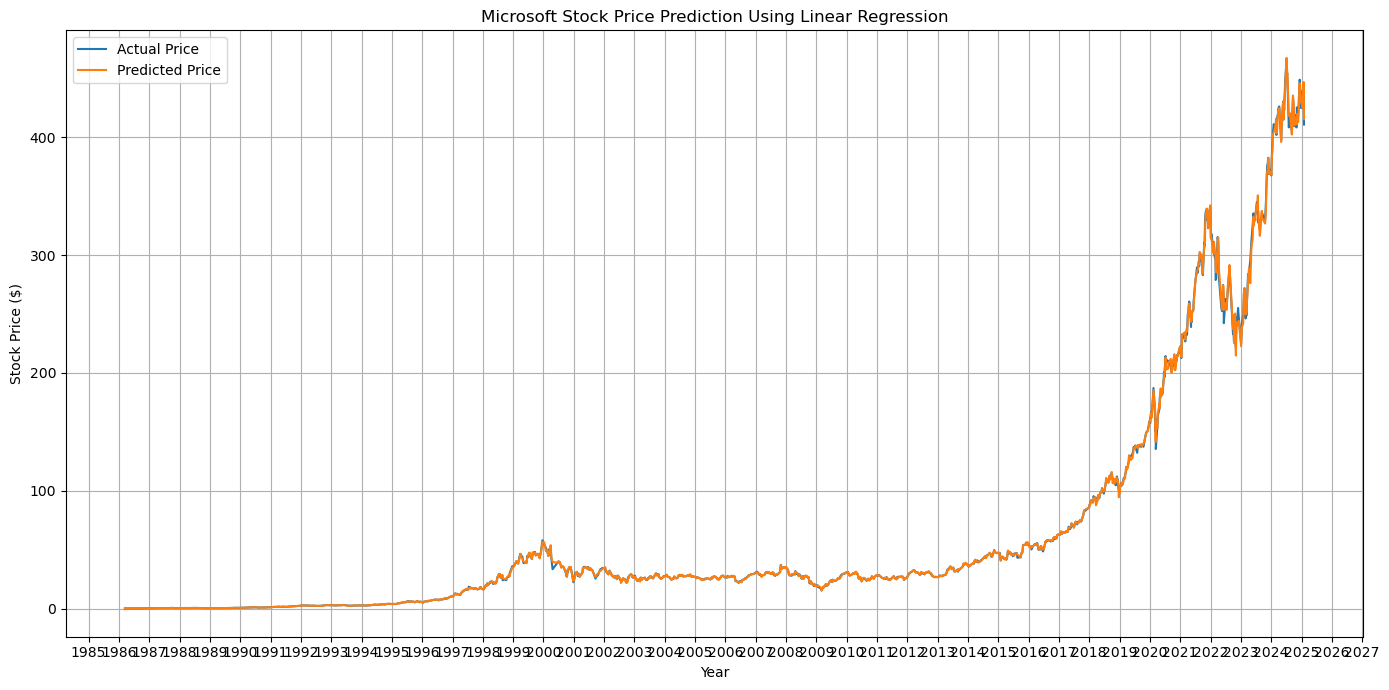


Project Completed Successfully


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# =====================================
# STOCK PRICE PREDICTION PROJECT
# =====================================

# Load Dataset
file_path = r"C:\Users\techn\codec_ai_pro\microsoft_stock_data.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully\n")
print(df.head())

# =====================================
# DATA CLEANING
# =====================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

df.sort_values('Date', inplace=True)

df.reset_index(drop=True, inplace=True)

print("\nDataset Cleaned Successfully")

# =====================================
# CREATE TARGET VARIABLE
# Predict Next Day Closing Price
# =====================================

df['Prediction'] = df['Close'].shift(-1)

df.dropna(inplace=True)

# =====================================
# FEATURES & LABEL
# =====================================

X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Prediction']

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# MODEL TRAINING
# =====================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed")

# =====================================
# PREDICTION
# =====================================

predictions = model.predict(X_test)

print("\nSample Predictions:")
print(predictions[:5])

# =====================================
# ACCURACY
# =====================================

accuracy = model.score(X_test, y_test)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# =====================================
# NEXT DAY PREDICTION
# =====================================

last_row = df[['Open', 'High', 'Low', 'Close', 'Volume']].iloc[-1:]

next_day_price = model.predict(last_row)

print("\nPredicted Next Day Closing Price:")
print(round(next_day_price[0], 2))

# =====================================
# SAVE MODEL
# =====================================

with open("stock_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel Saved Successfully")

# =====================================
# GRAPH WITH YEAR FORMAT
# =====================================

test_dates = df.loc[X_test.index, 'Date']

plot_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_test,
    'Predicted': predictions
})

plot_df = plot_df.sort_values('Date')

plt.figure(figsize=(14, 7))

plt.plot(
    plot_df['Date'],
    plot_df['Actual'],
    label='Actual Price'
)

plt.plot(
    plot_df['Date'],
    plot_df['Predicted'],
    label='Predicted Price'
)

# Show years only (2022, 2023, 2024, 2025 ...)
ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Microsoft Stock Price Prediction Using Linear Regression")

plt.xlabel("Year")

plt.ylabel("Stock Price ($)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("\nProject Completed Successfully")